In [1]:
from R0_values import *
import matplotlib.pyplot as plt

# Define parameter ranges
param_ranges = {
    "beta_d": np.linspace(0.01, 0.5, 100),
    "beta_i": np.linspace(0.01, 0.5, 100),
    "mu": np.linspace(0.01, 0.5, 100),
    "alpha": np.linspace(0.01, 0.5, 100),
    "gamma": np.linspace(0.01, 0.5, 100)
}

# R0 ranges for each parameter
R0_ranges_minMax = {
    "beta_d": (min(beta_d_R0_values()), max(beta_d_R0_values())),
    "beta_i": (min(beta_i_R0_values()), max(beta_i_R0_values())),
    "mu": (min(mu_R0_values()), max(mu_R0_values())),
    "alpha": (min(alpha_R0_values()), max(alpha_R0_values())),
    "gamma": (min(gamma_R0_values()), max(gamma_R0_values())),
}


R0_ranges = {
    "beta_d": beta_d_R0_values(),
    "beta_i": beta_i_R0_values(),
    "mu": mu_R0_values(),
    "alpha": (min(alpha_R0_values()), max(alpha_R0_values())),
    "gamma": (min(gamma_R0_values()), max(gamma_R0_values())),
}

# Compute sensitivity index for each parameter (NRS)
sensitivity = {}
for param in param_ranges.keys():
    delta_X = np.max(param_ranges[param]) - np.min(param_ranges[param])
    delta_R0 = np.max(R0_ranges_minMax[param]) - np.min(R0_ranges_minMax[param])

    X_avg = np.mean(param_ranges[param])
    R0_avg = np.mean(R0_ranges[param])

    S_X = (delta_R0 / R0_avg) / (delta_X / X_avg)
    sensitivity[param] = S_X

# Sorting params
sorted_sensitivity = sorted(sensitivity.items(), key=lambda x: x[1], reverse=True)


for param, S_X in sorted_sensitivity:
    print(f"Parameter: {param}, Sensitivity Index: {S_X:.3f}")

Parameter: gamma, Sensitivity Index: 6.033
Parameter: mu, Sensitivity Index: 1.018
Parameter: beta_d, Sensitivity Index: 0.914
Parameter: beta_i, Sensitivity Index: 0.872
Parameter: alpha, Sensitivity Index: 0.754


## Normalized Relative Sensitivity Analysis

First, I found an analysis: a general relative sensitivity index $S_x$ for each parameter $X$ which is represented by the following equation:


$${S_x} = \frac{{\Delta R_0}/{R_{0avg}}}{{\Delta X}/{X_{avg}}} $$

where $\Delta R_0$, for every $R_0$ value of parameter $X$, is:

$$\Delta R_0 = R_{0max} -  R_{0min}$$

and $R_{0avg}$ is:

$$\frac{1}{N} \sum R_0 $$ where N is length of $R_0$. It's important to note that $R_0$ refers to:

$$R_0 = \frac{\beta_d}{\gamma} + \frac{\beta_i}{\gamma} * \frac{\alpha}{\mu}$$



$X$ here is the parameter. $\Delta X$ is:

$$\Delta X = X_{max} -  X_{min}$$

and $X_{avg}$ is:

$$\frac{1}{N} \sum X $$ where N is length of $X$.

Taking these into account, for each parameter, I compute:

$${S_x} = \frac{(R_{0max} - R_{0min})/R_{0avg}}{(X_{max} - X_{min})/X_{avg}} $$



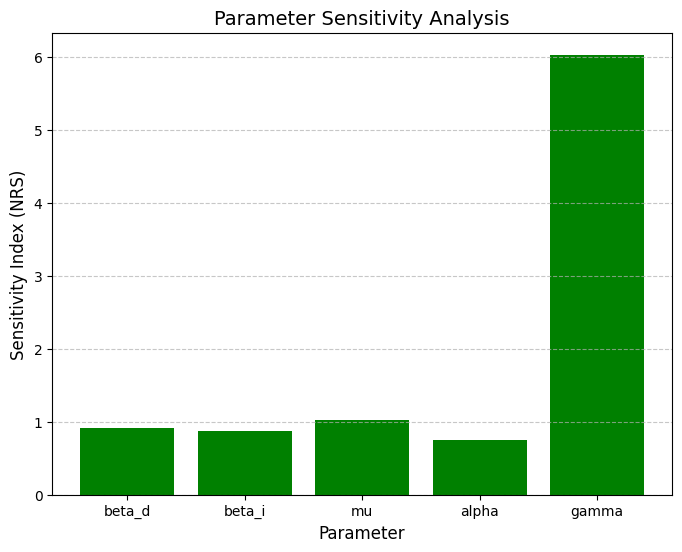

In [2]:
plt.figure(figsize=(8, 6))
plt.bar(sensitivity.keys(), sensitivity.values(), color='green')
plt.xlabel("Parameter", fontsize=12)
plt.ylabel("Sensitivity Index (NRS)", fontsize=12)
plt.title("Parameter Sensitivity Analysis", fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()